# 03 · Влияние на бизнес и рекомендации

Связываем IT-поддержку с операционной деятельностью аэропорта: нагрузка от рейсов, удовлетворённость пользователей, влияние инцидентов на рейсы — и формулируем рекомендации.

In [1]:
%matplotlib inline
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from analysis import load_data, NAVY, STEEL, SKY, ORANGE, RED, GREEN, WD_ORDER
pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.grid': True,
                     'grid.color': '#e8ecf0', 'axes.unicode_minus': False})
t, flights, sla, systems, agents = load_data()
print('Обращений:', len(t), '| период:', t.created_at.min().date(), '—', t.created_at.max().date())
t.head(3)

Обращений: 33309 | период: 2024-01-01 — 2025-12-31


,ticket_id,created_at,first_response_at,resolved_at,status,priority,category,system,criticality,is_critical_for_flights,zone,channel,reporter_role,team,agent_id,...,sla_breached,reopened,service_downtime_min,delayed_flights,csat,date,hour,weekday,weekday_name,month,year,ym,resolution_hours,is_closed,is_open
0,DME-000001,2024-01-01 00:10:07,2024-01-01 00:24:07,2024-01-01 00:51:07,Закрыт,P2,Периферия,Рабочие станции (АРМ),Низкая,False,Служебные зоны,Телефон,Администрация аэропорта,1-я линия поддержки,AG-105,...,False,False,0,0,5.0,2024-01-01,0,0,Пн,1,2024,2024-01,0.683333,True,False
1,DME-000002,2024-01-01 00:24:48,2024-01-01 00:32:48,2024-01-01 00:50:48,Закрыт,P3,Периферия,Принтеры посадочных талонов,Средняя,True,Зона регистрации,Телефон,Авиакомпания,1-я линия поддержки,AG-102,...,False,False,0,0,5.0,2024-01-01,0,0,Пн,1,2024,2024-01,0.433333,True,False
2,DME-000003,2024-01-01 02:07:42,2024-01-01 02:18:42,2024-01-01 05:25:42,Закрыт,P3,Оборудование,Рабочие станции (АРМ),Низкая,False,ЦОД и серверная,Телефон,Операционный центр,Полевая служба,AG-126,...,False,False,0,0,4.0,2024-01-01,2,0,Пн,1,2024,2024-01,3.300000,True,False


## Нагрузка на поддержку и объём рейсов

Строим простую модель зависимости числа обращений от числа рейсов в день.

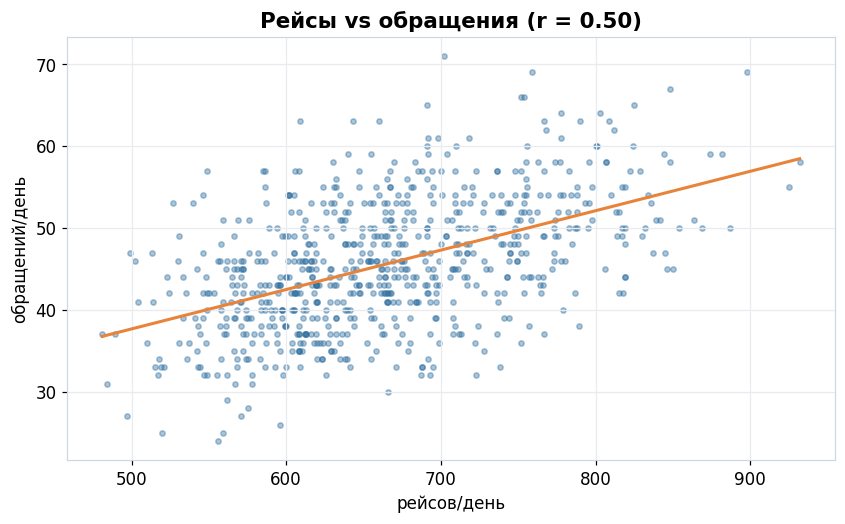

Модель: обращений ≈ 0.048 × рейсы + 14
Каждые +100 рейсов в день дают примерно +5 обращений


In [2]:
daily = t.groupby('date').size().rename('tickets').reset_index()
mg = daily.merge(flights[['date','flights_scheduled']], on='date')
r = np.corrcoef(mg.flights_scheduled, mg.tickets)[0,1]
z = np.polyfit(mg.flights_scheduled, mg.tickets, 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(mg.flights_scheduled, mg.tickets, s=12, alpha=.4, color=STEEL)
xs = np.linspace(mg.flights_scheduled.min(), mg.flights_scheduled.max(), 50)
ax.plot(xs, np.polyval(z, xs), color=ORANGE, lw=2)
ax.set_title(f'Рейсы vs обращения (r = {r:.2f})'); ax.set_xlabel('рейсов/день'); ax.set_ylabel('обращений/день')
plt.show()
print(f'Модель: обращений ≈ {z[0]:.3f} × рейсы + {z[1]:.0f}')
print(f'Каждые +100 рейсов в день дают примерно +{z[0]*100:.0f} обращений')

## Что снижает удовлетворённость (CSAT)

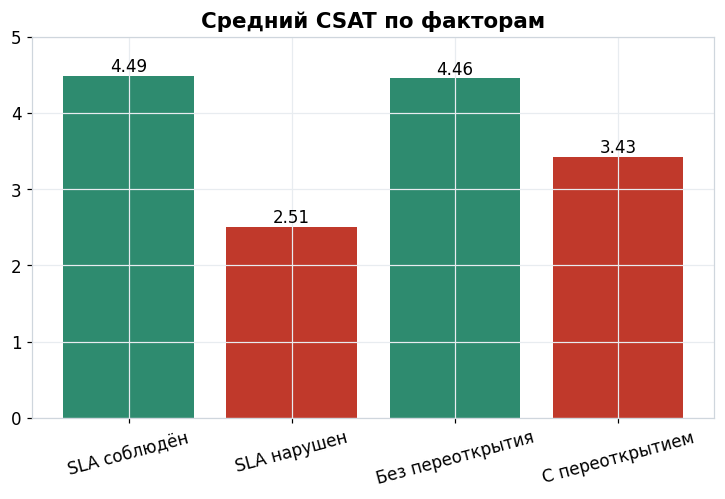

In [3]:
cc = t[t.csat.notna()]
g = {'SLA соблюдён': cc[~cc.sla_breached].csat.mean(), 'SLA нарушен': cc[cc.sla_breached].csat.mean(),
     'Без переоткрытия': cc[~cc.reopened].csat.mean(), 'С переоткрытием': cc[cc.reopened].csat.mean()}
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(list(g.keys()), list(g.values()), color=[GREEN, RED, GREEN, RED])
ax.set_ylim(0, 5); ax.set_title('Средний CSAT по факторам'); ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(g.values()): ax.text(i, v+0.05, f'{v:.2f}', ha='center')
plt.show()

## Операционное влияние критических инцидентов

Критические инциденты (P1) на ключевых системах приводят к простоям и задержкам рейсов.

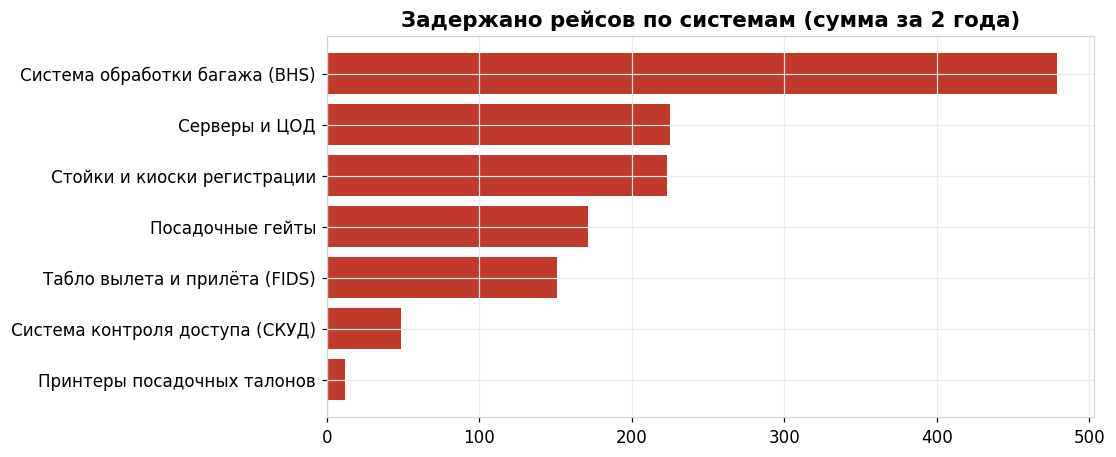

Всего задержано рейсов: 1310 | в год ≈ 655
Суммарный простой критичных систем, ч: 1160


In [4]:
imp = t[t.delayed_flights > 0]
by = imp.groupby('system').delayed_flights.sum().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(by.index, by.values, color=RED)
ax.set_title('Задержано рейсов по системам (сумма за 2 года)'); plt.show()
print('Всего задержано рейсов:', int(t.delayed_flights.sum()), '| в год ≈', int(t.delayed_flights.sum()/2))
print('Суммарный простой критичных систем, ч:', int(t.service_downtime_min.sum()/60))

## Нагрузка по интервалам суток — основа для смен

In [5]:
band = pd.cut(t.hour, bins=[-1,5,9,16,19,23],
              labels=['Ночь 0–5','Утро 6–9','День 10–16','Вечер 17–19','Поздний 20–23'])
load = (t.groupby(band).size() / t.date.nunique()).round(1)
print('Средняя нагрузка по интервалам (обращений/день):')
print(load.to_string())

Средняя нагрузка по интервалам (обращений/день):
hour
Ночь 0–5          3.2
Утро 6–9         12.6
День 10–16       14.4
Вечер 17–19       9.8
Поздний 20–23     5.6


## Выводы и рекомендации

**Ключевые находки**
1. Первичная **реакция — главное узкое место**: срыв SLA по реакции ~31%, сконцентрирован в утренний и вечерний пик.
2. **Решение** укладывается в срок почти везде, кроме **P1** (критические) и систем **BHS**/**серверы** — самых сложных.
3. Нагрузка на поддержку **растёт вместе с рейсами** (r≈0.5) и год к году.
4. Нарушение SLA обваливает CSAT в ~1.8 раза — качество сервиса напрямую зависит от сроков.
5. IT-инциденты стали причиной **~655 задержек рейсов в год**.

**Рекомендации**
- **Усилить 1-ю линию в пик** (06:00–09:00 и 17:00–19:00) — прямой способ снять срывы реакции.
- **Профилактика по BHS и серверам**: мониторинг и предиктивное обслуживание сократят долгие P1 и задержки рейсов.
- **Обновление парка киосков регистрации и АРМ** — лидеров по числу обращений.
- **Планирование ёмкости от расписания рейсов**: модель «рейсы → обращения» позволяет прогнозировать нагрузку и заранее ставить смены.
- **Работа с переоткрытиями**: контроль качества решения повысит CSAT.